In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from pathlib import Path

from hcc_multimodal.baselines.data import add_rfs_columns
from hcc_multimodal.baselines.transforms import DataType
from hcc_multimodal.baselines.evaluation import (
    run_cv_experiment,
    plot_cv_results,
    DeseqCPMSelector,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from itertools import product

In [3]:
RANDOM_STATE = 42
RNA_COUNT_FILTER = 15
RNA_COUNT_FILTER_MIN_SAMPLES = 5
DESEQ_PVALUE = 0.1
DESEQ_MIN_FEATURES = 20
RFS_YEARS = [1, 2]
CV_N_FOLDS = 4

# Read data

In [4]:
ROOT = Path().resolve().parents[1]


clinical_data = pd.read_csv(
    ROOT
    / "data"
    / "Clinical"
    / "2025_Nov_18_ICL_Resection_Clinical_Outcome_soramic_format.csv"
).dropna(how="all")

rna_data = pd.read_csv(
    ROOT / "data" / "RNA_seq" / "Matrix_output_radiology_only.csv"
).dropna(how="all")

In [5]:
columns = rna_data["Gene Symbol"]
rna_data = rna_data.T.iloc[2:, :]
rna_data.columns = columns.values

# Drop columns with NaN gene symbols and deduplicate gene names
rna_data = rna_data.loc[:, ~pd.isnull(rna_data.columns)]
rna_data = rna_data.loc[:, ~rna_data.columns.duplicated()]

# Convert expression values to numeric, make SID an integer column
rna_data = rna_data.apply(pd.to_numeric, errors="coerce")
rna_data.index = rna_data.index.astype(int)
rna_data = rna_data.rename_axis("SID").reset_index()

print(f"RNA data shape (patients × genes): {rna_data.shape}")
rna_data.head()

RNA data shape (patients × genes): (60, 50987)


,SID,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,AC134980.5,AL691520.1,AC139491.7,AC021097.2,AL590381.1,AC003043.2,AC135068.11,AL356417.3,AC104389.6,AP000646.1
0,39,0,0,0,0,0,0,245,0,0,...,0,0,0,0,0,0,0,0,0,0
1,31,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,66,150,0,153,0,0,0,828,63,0,...,0,0,0,0,0,0,0,0,0,0
3,33,139,0,0,0,0,0,3206,0,224,...,0,0,0,0,0,1,0,3,0,0
4,132,0,0,0,0,37,2,985,0,236,...,0,0,0,0,0,1,0,0,0,0


# RFS column

In [ ]:
clinical_data = add_rfs_columns(clinical_data)
clinical_data[["RFS_central", "RFS_central_event", "rfs_1year", "rfs_2year"]].head(10)

In [7]:
clinical_data[["RFS_central", "RFS_central_event", "rfs_1year", "rfs_2year"]].tail(10)

,RFS_central,RFS_central_event,rfs_1year,rfs_2year
59,52.734247,0.0,0.0,0.0
60,63.813699,1.0,0.0,0.0
61,75.879452,0.0,0.0,0.0
62,2.367123,0.0,NaN,NaN
63,7.791781,1.0,1.0,1.0
64,5.983562,1.0,1.0,1.0
65,5.786301,1.0,1.0,1.0
66,132.526027,1.0,0.0,0.0
67,27.320548,1.0,0.0,0.0
68,97.347945,0.0,0.0,0.0


In [8]:
print(clinical_data["rfs_1year"].value_counts(dropna=False))
print(clinical_data["rfs_2year"].value_counts(dropna=False))

rfs_1year
0.0    43
1.0    21
NaN     5
Name: count, dtype: int64
rfs_2year
0.0    34
1.0    28
NaN     7
Name: count, dtype: int64


In [9]:
rna_count = rna_data.drop(columns=["SID"])
rna_count.index = rna_data["SID"]
print("Before filtering:", rna_count.shape[1])
rna_count_flt = rna_count.loc[
    :, (rna_count >= RNA_COUNT_FILTER).sum(axis=0) >= RNA_COUNT_FILTER_MIN_SAMPLES
]
print("After filtering:", rna_count_flt.shape[1])
rna_count_flt.head()

Before filtering: 50986
After filtering: 27991


,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AC087564.1,FO393400.1,AC104162.2,AL033530.1,GABPB1-IT1,BX571818.1,AC093827.5,AC139491.7,AC135068.11,AL356417.3
SID,,,,,,,,,,,,,,,,,,,,,
39,0,0,0,0,0,0,245,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
66,150,0,153,0,0,0,828,63,0,82,...,0,0,123,0,0,0,0,0,0,0
33,139,0,0,0,0,0,3206,0,224,0,...,98,0,15,0,0,0,64,0,0,3
132,0,0,0,0,37,2,985,0,236,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
rna_rfs = rna_count_flt.merge(
    clinical_data[["SID", "rfs_1year", "rfs_2year"]], on="SID"
)
rna_rfs = rna_rfs.set_index("SID")
rna_rfs.head()

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AC104162.2,AL033530.1,GABPB1-IT1,BX571818.1,AC093827.5,AC139491.7,AC135068.11,AL356417.3,rfs_1year,rfs_2year
SID,,,,,,,,,,,,,,,,,,,,,
39,0,0,0,0,0,0,245,0,0,0,...,0,0,0,0,0,0,0,0,0.0,0.0
31,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0.0,1.0
66,150,0,153,0,0,0,828,63,0,82,...,123,0,0,0,0,0,0,0,NaN,NaN
33,139,0,0,0,0,0,3206,0,224,0,...,15,0,0,0,64,0,0,3,0.0,1.0
132,0,0,0,0,37,2,985,0,236,0,...,0,0,0,0,0,0,0,0,NaN,NaN


# CV experiments

In [11]:
selector = DeseqCPMSelector(pvalue=DESEQ_PVALUE, min_features=DESEQ_MIN_FEATURES)

In [ ]:
OUTPUT_DIR = ROOT / "notebooks" / "baselines" / f"{CV_N_FOLDS}_folds"
OUTPUT_DIR.mkdir(exist_ok=True)

[RFS 1 year - RNA-seq]  n=56  positives=19  features=27991
Using None as control genes, passed at DeseqDataSet initialization


/Users/amo/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Fitting size factors...
... done in 0.01 seconds.



Fitting dispersions...


... done in 1.15 seconds.

Fitting dispersion trend curve...
... done in 0.18 seconds.

Fitting MAP dispersions...


... done in 1.20 seconds.

Fitting LFCs...


...

... done in 0.45 seconds.

Fitting LFCs...


... done in 1.02 seconds.



Running Wald tests...


... done in 0.50 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TSPAN6        73.484853       -0.139244  1.734956 -0.080258  0.936032   
TNMD           4.180963       -4.874243  2.938834 -1.658563  0.097204   
DPM1         213.726768       -0.614129  1.739276 -0.353095  0.724017   
SCYL3        146.179605       -0.283042  1.675571 -0.168922  0.865858   
C1orf112      69.578929       -0.536086  1.836973 -0.291831  0.770416   
...                 ...             ...       ...       ...       ...   
BX571818.1     6.984414       -5.037668  2.484052 -2.028004  0.042560   
AC093827.5     1.774372       -1.818783  2.785538 -0.652938  0.513796   
AC139491.7     9.355588       -5.561393  2.474474 -2.247505  0.024608   
AC135068.11    0.124349        1.153850  3.197564  0.360853  0.718209   
AL356417.3    23.855298       -3.010136  1.246523 -2.414826  0.015743   

                 padj  
TSPAN6       0.999906  
TNMD         0.99990

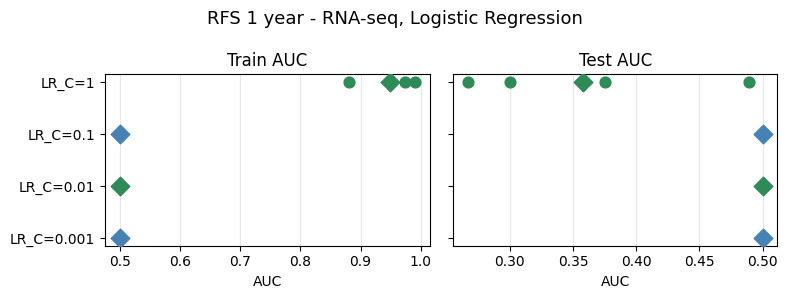

[RFS 1 year - RNA-seq]  n=56  positives=19  features=27991
Using None as control genes, passed at DeseqDataSet initialization


/Users/amo/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Fitting size factors...
... done in 0.01 seconds.



Fitting dispersions...


... done in 1.34 seconds.

Fitting dispersion trend curve...
... done in 0.19 seconds.

Fitting MAP dispersions...


... done in 1.15 seconds.

Fitting LFCs...


...

... done in 0.41 seconds.

Fitting LFCs...


... done in 1.03 seconds.



Running Wald tests...


... done in 0.47 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TSPAN6        73.484853       -0.139244  1.734956 -0.080258  0.936032   
TNMD           4.180963       -4.874243  2.938834 -1.658563  0.097204   
DPM1         213.726768       -0.614129  1.739276 -0.353095  0.724017   
SCYL3        146.179605       -0.283042  1.675571 -0.168922  0.865858   
C1orf112      69.578929       -0.536086  1.836973 -0.291831  0.770416   
...                 ...             ...       ...       ...       ...   
BX571818.1     6.984414       -5.037668  2.484052 -2.028004  0.042560   
AC093827.5     1.774372       -1.818783  2.785538 -0.652938  0.513796   
AC139491.7     9.355588       -5.561393  2.474474 -2.247505  0.024608   
AC135068.11    0.124349        1.153850  3.197564  0.360853  0.718209   
AL356417.3    23.855298       -3.010136  1.246523 -2.414826  0.015743   

                 padj  
TSPAN6       0.999906  
TNMD         0.99990

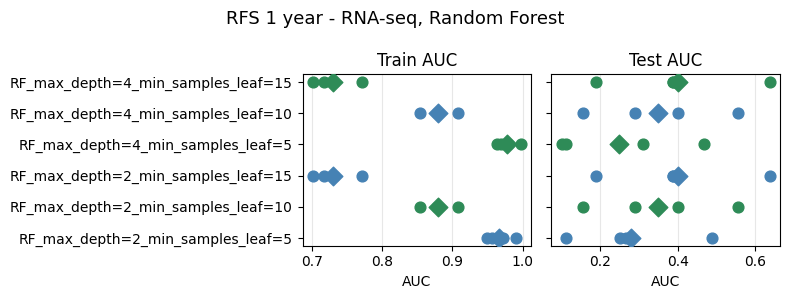

[RFS 2 year - RNA-seq]  n=54  positives=25  features=27991
Using None as control genes, passed at DeseqDataSet initialization


/Users/amo/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Fitting size factors...
... done in 0.01 seconds.



Fitting dispersions...


... done in 1.27 seconds.

Fitting dispersion trend curve...
... done in 0.20 seconds.



Fitting MAP dispersions...


...

... done in 0.41 seconds.

Fitting LFCs...


... done in 0.89 seconds.



Running Wald tests...


Log2 fold change & Wald test p-value: condition 1 vs 0
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TSPAN6       189.962342       -1.559301  1.453409 -1.072858  0.283335   
TNMD          15.654881        1.531877  1.888740  0.811058  0.417332   
DPM1         184.496017       -0.828910  1.416619 -0.585133  0.558459   
SCYL3        153.268626       -0.154944  1.266560 -0.122335  0.902634   
C1orf112      96.978997       -0.723233  1.382115 -0.523280  0.600780   
...                 ...             ...       ...       ...       ...   
BX571818.1     4.347407       -4.291913  2.106975 -2.037002  0.041650   
AC093827.5     2.016023       -1.793752  2.284903 -0.785045  0.432427   
AC139491.7     1.602225       -1.255146  2.781957 -0.451174  0.651864   
AC135068.11    3.069561        4.942409  2.932900  1.685161  0.091958   
AL356417.3     4.720909        0.091504  1.181534  0.077445  0.938270   

                 padj  
TSPAN6       0.999951  
TNMD         0.99995

... done in 0.45 seconds.



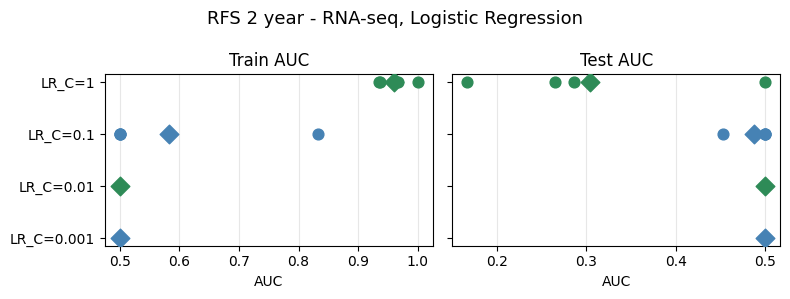

/Users/amo/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
Fitting size factors...


[RFS 2 year - RNA-seq]  n=54  positives=25  features=27991
Using None as control genes, passed at DeseqDataSet initialization


... done in 0.01 seconds.



Fitting dispersions...


... done in 1.22 seconds.

Fitting dispersion trend curve...
... done in 0.18 seconds.

Fitting MAP dispersions...


...

... done in 0.41 seconds.

Fitting LFCs...


... done in 0.83 seconds.



Running Wald tests...


... done in 0.44 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TSPAN6       189.962342       -1.559301  1.453409 -1.072858  0.283335   
TNMD          15.654881        1.531877  1.888740  0.811058  0.417332   
DPM1         184.496017       -0.828910  1.416619 -0.585133  0.558459   
SCYL3        153.268626       -0.154944  1.266560 -0.122335  0.902634   
C1orf112      96.978997       -0.723233  1.382115 -0.523280  0.600780   
...                 ...             ...       ...       ...       ...   
BX571818.1     4.347407       -4.291913  2.106975 -2.037002  0.041650   
AC093827.5     2.016023       -1.793752  2.284903 -0.785045  0.432427   
AC139491.7     1.602225       -1.255146  2.781957 -0.451174  0.651864   
AC135068.11    3.069561        4.942409  2.932900  1.685161  0.091958   
AL356417.3     4.720909        0.091504  1.181534  0.077445  0.938270   

                 padj  
TSPAN6       0.999951  
TNMD         0.99995

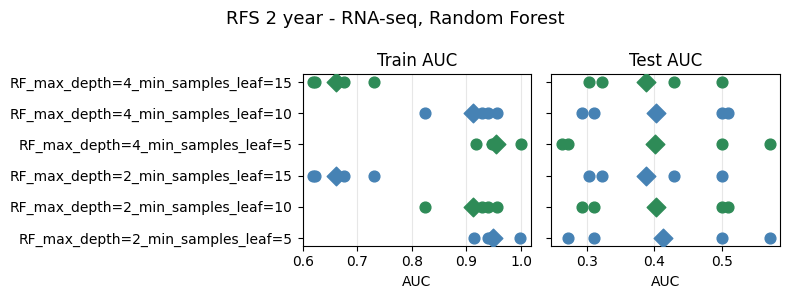

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,RFS 1 year - RNA-seq,LR_C=0.001,0.500,0.000,0.661,0.031
1,RFS 1 year - RNA-seq,LR_C=0.01,0.500,0.000,0.661,0.031
2,RFS 1 year - RNA-seq,LR_C=0.1,0.500,0.000,0.661,0.031
3,RFS 1 year - RNA-seq,LR_C=1,0.358,0.085,0.464,0.107
4,RFS 1 year - RNA-seq,RF_max_depth=2_min_samples_leaf=5,0.279,0.135,0.500,0.196
5,RFS 1 year - RNA-seq,RF_max_depth=2_min_samples_leaf=10,0.350,0.147,0.643,0.051
6,RFS 1 year - RNA-seq,RF_max_depth=2_min_samples_leaf=15,0.401,0.159,0.661,0.031
7,RFS 1 year - RNA-seq,RF_max_depth=4_min_samples_leaf=5,0.247,0.152,0.482,0.178
8,RFS 1 year - RNA-seq,RF_max_depth=4_min_samples_leaf=10,0.350,0.147,0.643,0.051
9,RFS 1 year - RNA-seq,RF_max_depth=4_min_samples_leaf=15,0.401,0.159,0.661,0.031


In [ ]:
X = rna_rfs.drop(columns=["rfs_1year", "rfs_2year"])
x_columns = {col: DataType.CONTINUOUS for col in X}

all_records = []

for RFS_YEAR in RFS_YEARS:
    y = rna_rfs[f"rfs_{RFS_YEAR}year"]
    EXPERIMENT_LABEL = f"RFS {RFS_YEAR} year - RNA-seq"

    # --- Logistic Regression ---
    MODELS_LR = {
        f"LR_C={c}": LogisticRegression(
            solver="liblinear",
            l1_ratio=1.0,
            C=c,
            max_iter=1000,
            random_state=RANDOM_STATE,
        )
        for c in [0.001, 0.01, 0.1, 1]
    }
    records_lr, fold_records_lr = run_cv_experiment(
        X,
        y,
        x_columns,
        EXPERIMENT_LABEL,
        feature_selector=selector,
        selector_first=True,
        models=MODELS_LR,
        n_splits=CV_N_FOLDS,
    )
    plot_cv_results(
        fold_records_lr,
        title=f"{EXPERIMENT_LABEL}, Logistic Regression",
        save_path=OUTPUT_DIR / f"rfs_{RFS_YEAR}y_lr.png",
    )

    # --- Random Forest ---
    MODELS_RF = {
        f"RF_max_depth={d}_min_samples_leaf={m}": RandomForestClassifier(
            max_depth=d, min_samples_leaf=m, random_state=RANDOM_STATE
        )
        for d, m in product([2, 4], [5, 10, 15])
    }
    records_rf, fold_records_rf = run_cv_experiment(
        X,
        y,
        x_columns,
        EXPERIMENT_LABEL,
        feature_selector=selector,
        selector_first=True,
        models=MODELS_RF,
        n_splits=CV_N_FOLDS,
    )
    plot_cv_results(
        fold_records_rf,
        title=f"{EXPERIMENT_LABEL}, Random Forest",
        save_path=OUTPUT_DIR / f"rfs_{RFS_YEAR}y_rf.png",
    )

    # Save selected features (one CSV per model type per year, all folds combined)
    for fold_records, model_type in [(fold_records_lr, "lr"), (fold_records_rf, "rf")]:
        feats = []
        for _, row in fold_records.iterrows():
            if row["selected_features"] is not None:
                df = row["selected_features"].copy()
                df["fold"] = row["fold"]
                df["model"] = row["model"]
                feats.append(df)
        if feats:
            (
                pd.concat(feats, ignore_index=True).to_csv(
                    OUTPUT_DIR / f"rfs_{RFS_YEAR}y_{model_type}_selected_features.csv",
                    index=False,
                )
            )

    all_records.extend([records_lr, records_rf])

summary = pd.concat(all_records, ignore_index=True)
display(summary)